<a href="https://colab.research.google.com/github/tixomirof/mo2_team_colabs/blob/main/%D0%9C%D0%9E2_%D0%9A%D0%BE%D0%BC%D0%B0%D0%BD%D0%B4%D0%B02_%D0%9B%D0%B0%D0%B104_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Шапка
Проектная работа. Группа №2. Обучение с учителем: KNN.

Участники команды:

* Ибраева Асем
* Киреева Анастасия
* Рудин Валентин
* Тихомиров Алексей

#KNN

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

Загрузим датасет, полученный в результате первой лабораторной работы

In [ ]:
df = pd.read_csv("Engineered_Data.csv")
df.head()

,Employment,YearsCode,YearsCodePro,PreviousSalary,ComputerSkills,Employed,APL,ASP.NET,ASP.NET Core,AWS,...,Age_>35,Accessibility_Yes,EdLevel_NoHigherEd,EdLevel_Other,EdLevel_PhD,EdLevel_Undergraduate,Gender_NonBinary,Gender_Woman,MentalHealth_Yes,MainBranch_NotDev
0,1,7.0,4,51552.0,4,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,1,12.0,5,46482.0,12,1,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
2,1,15.0,6,77290.0,7,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,1,9.0,6,46135.0,13,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
4,0,40.0,30,160932.0,2,0,0,0,0,0,...,True,False,False,False,True,False,False,False,False,True


Разделим данные, выделим признаки X и целевую переменную y

In [ ]:
X = df.drop('Employed',axis=1)
y = df['Employed']

##Разбиение на обучающий и тестовый наборы данных

Разделим данные на обучающий (70%) и тестовый (30%) наборы данных и масштабируем данные

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [ ]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

##Метод локтя для выбора хороших значений K

In [ ]:
test_error_rates = []
for k in range(1,30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train,y_train)

    y_pred_test = knn_model.predict(scaled_X_test)

    test_error = 1 - accuracy_score(y_test,y_pred_test)
    test_error_rates.append(test_error)

Text(0.5, 0, 'K Value')

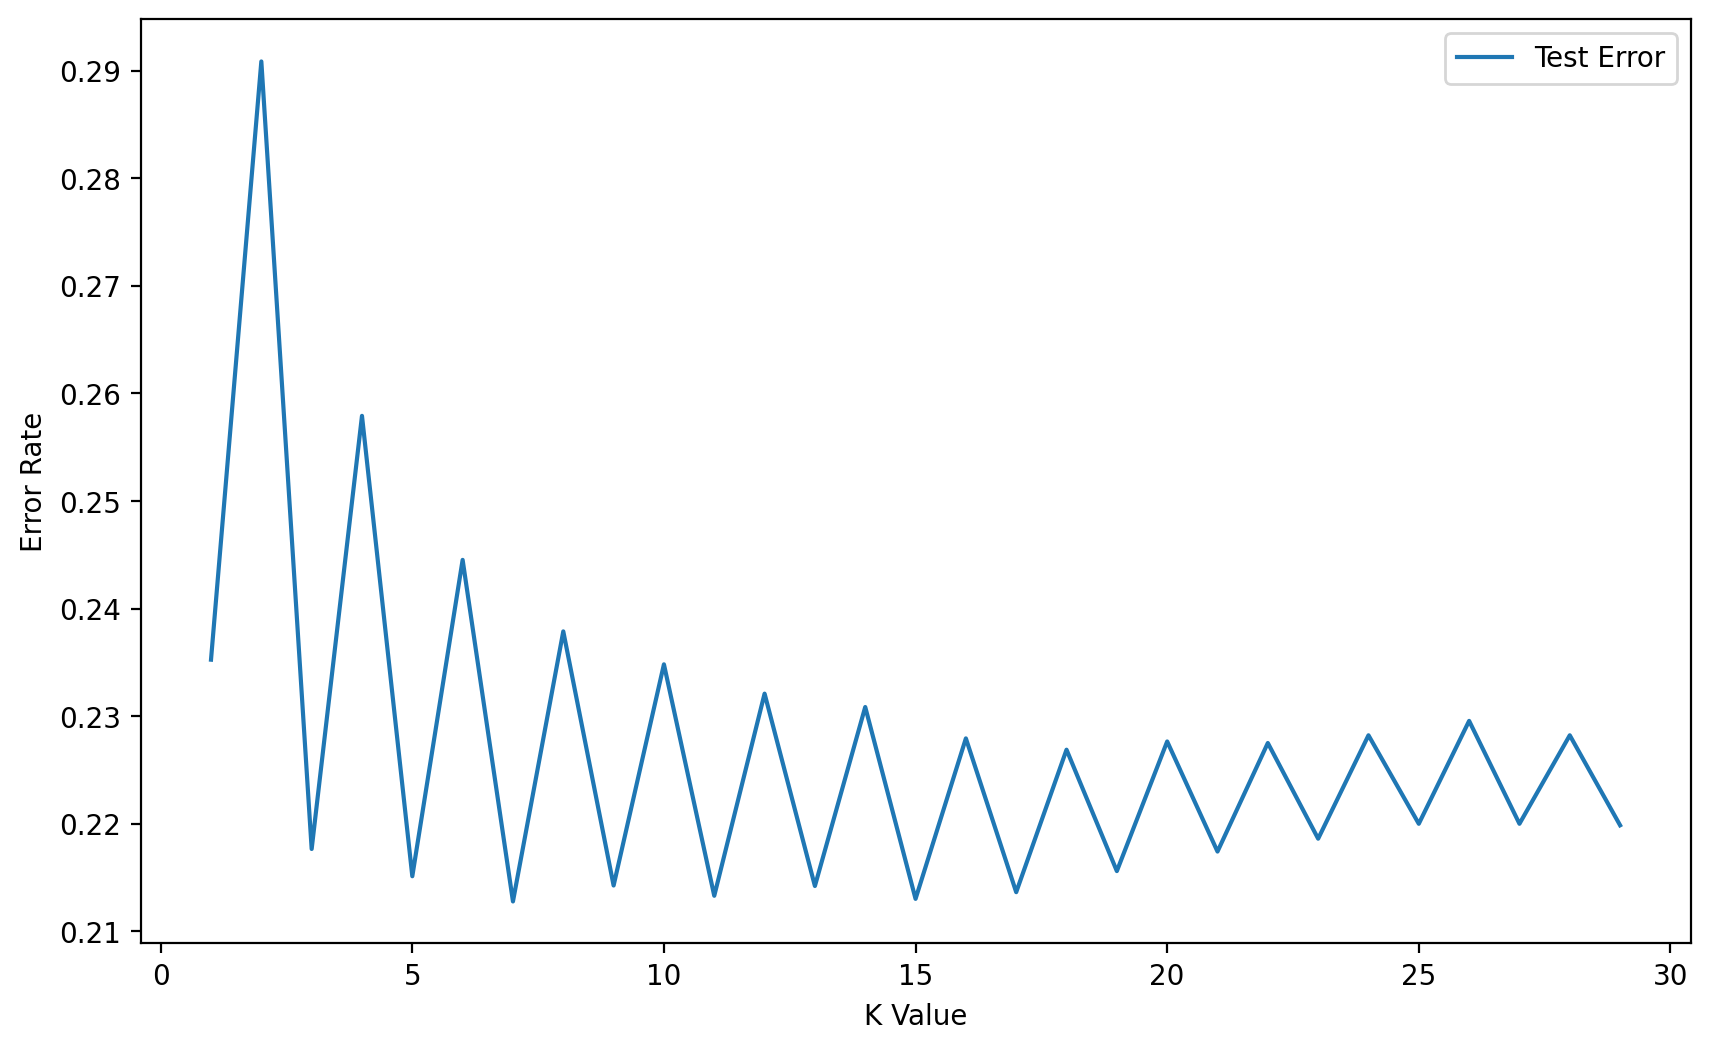

In [ ]:
plt.figure(figsize=(10,6),dpi=200)
plt.plot(range(1,30),test_error_rates,label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel("K Value")

Точка на графике, где происходит значительное снижение ошибки, а затем её уменьшение становится менее заметным и сменяется ростом, находится где-то в промежутке от 5 до 10. Поэтому по методу локтя оптимальным значением K будет какое-то значение из промежутка от 5 до 10.

##Кросс-валидация и поиск по сетке для значения K

Выполним поиск по сетке для различных значений К и выведим наилучшие параметры.
<br>В качестве K возьмем диапазон от 1 до 15 (по методу локтя наше оптимальное значение точно должно входить в этот промежуток)
<br>Также используем различные метрики расстояния: euclidean, manhattan, chebyshev, minkowski

In [ ]:
model = KNeighborsClassifier()
k_values = list(range(1, 15))
param_grid = {
    'n_neighbors': k_values,
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
}
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='accuracy'
)

In [ ]:
grid_search.fit(scaled_X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'chebyshev',
                                    'minkowski'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14]},
             scoring='accuracy')

In [ ]:
best_model = grid_search.best_estimator_
best_model.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'manhattan',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 9,
 'p': 2,
 'weights': 'uniform'}

Таким образом, наилучшими параметрами оказались:
* К = 9
* metric = manhattan

Используя словарь .cv_results_, нарисуем график средних тестовых оценок (mean_test_score) для каждого значения K.

In [ ]:
grid_search.cv_results_['mean_test_score']

array([0.7599426 , 0.70444854, 0.77949979, 0.73940139, 0.78218532,
       0.75188602, 0.78470685, 0.75776958, 0.78189832, 0.7596351 ,
       0.78105781, 0.76221812, 0.78050431, 0.76389914, 0.80352604,
       0.75371054, 0.82394424, 0.78880689, 0.82738827, 0.80174252,
       0.82949979, 0.80797458, 0.8296023 , 0.81076261, 0.82761378,
       0.81195162, 0.82738827, 0.81336613, 0.63851989, 0.60850759,
       0.65227552, 0.63501435, 0.65754408, 0.64432144, 0.65881509,
       0.64807298, 0.65875359, 0.650205  , 0.65832308, 0.64940549,
       0.6598811 , 0.65364904, 0.7599426 , 0.70444854, 0.77949979,
       0.73940139, 0.78218532, 0.75188602, 0.78470685, 0.75776958,
       0.78189832, 0.7596351 , 0.78105781, 0.76221812, 0.78050431,
       0.76389914])

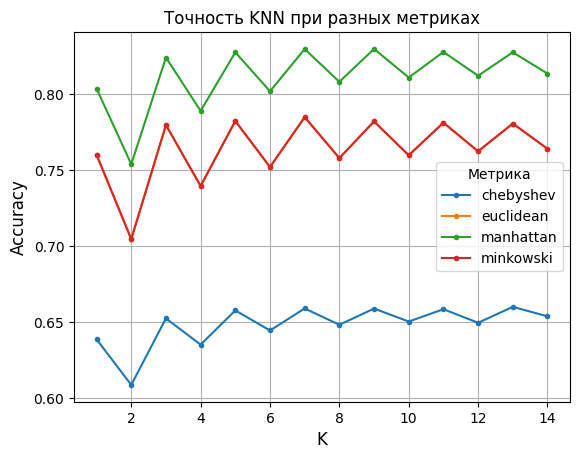

In [ ]:
results_df = pd.DataFrame(grid_search.cv_results_)

k_col = 'param_n_neighbors'
metric_col = 'param_metric'
score_col = 'mean_test_score'

pivot_table = results_df.pivot_table(index=k_col, columns=metric_col, values=score_col)

pivot_table.plot(marker='.')
plt.xlabel('K', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Точность KNN при разных метриках')
plt.legend(title='Метрика')
plt.grid(True)

plt.show()

Выведем отдельно график для евклидовой метрики, поскольку на общий график она почему-то не попала

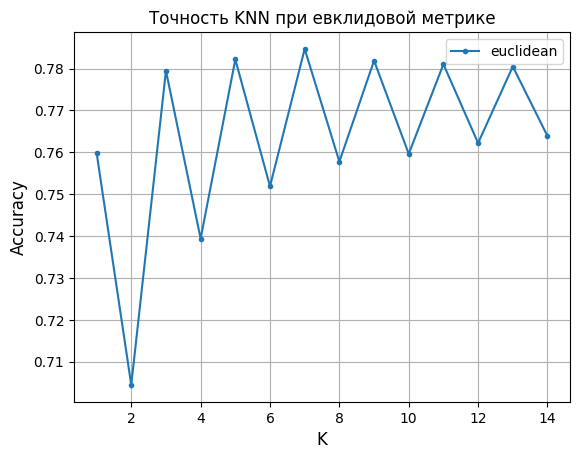

In [ ]:
if 'euclidean' in pivot_table.columns:
    pivot_table['euclidean'].plot(marker='.', legend=True)
    plt.xlabel('K', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Точность KNN при евклидовой метрике')
    plt.grid(True)
    plt.show()

Оказалось, что значения для метрик euclidean и minkowski совпадают, поэтому на общем графике не видно euclidean

По общему графику можно увидеть, что по метрике manhattan в целом результаты лучше, чем по другим метрикам.

##Финальная оценка модели

Создадим финальный отчёт "classification report" и матрицу "confusion matrix"

In [ ]:
y_pred = best_model.predict(scaled_X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.96      0.84      9690
           1       0.96      0.72      0.82     11216

    accuracy                           0.83     20906
   macro avg       0.85      0.84      0.83     20906
weighted avg       0.86      0.83      0.83     20906



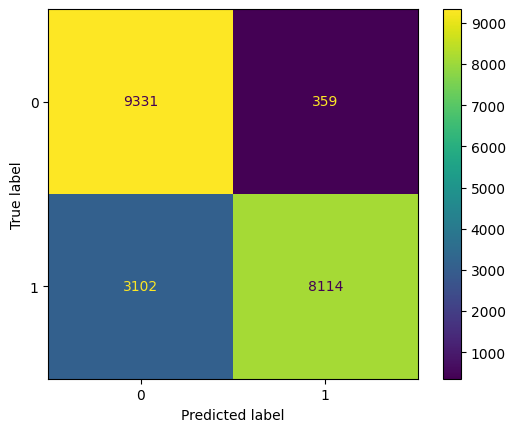

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

Сохраним лучшую модель

In [ ]:
import pickle

with open('best_knn.pkl', 'wb') as f:
    pickle.dump(best_model, f)